In [2]:
pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [5]:
df = pd.read_csv("heart.csv")

print("Shape Dataset:")
print(df.shape)

df.head()

Shape Dataset:
(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Data:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      

In [7]:
df.drop_duplicates(inplace=True)

print("Shape After Cleaning:")
print(df.shape)

Shape After Cleaning:
(302, 14)


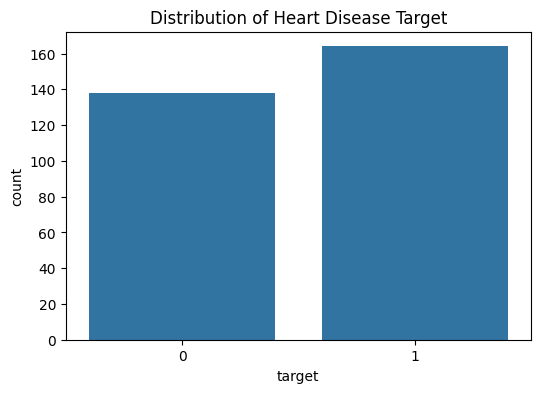

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Distribution of Heart Disease Target")
plt.show()

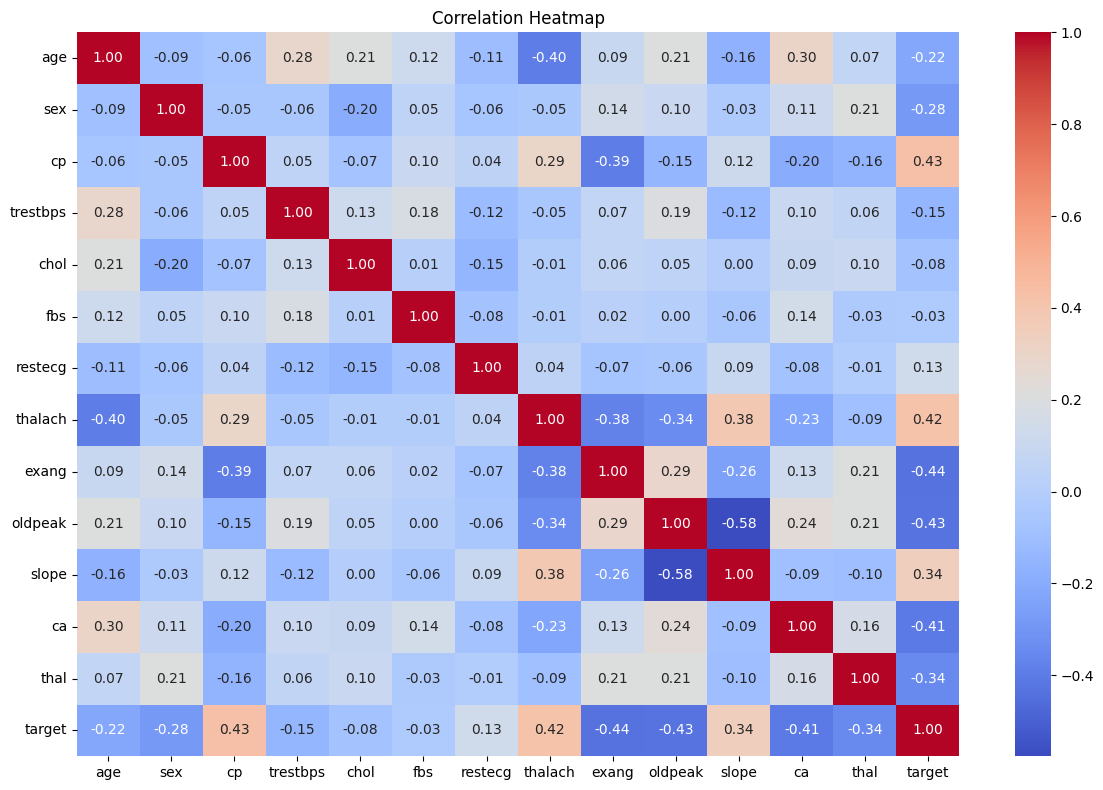

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

feature_names = X.columns

print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [13]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC(probability=True)
}

results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    trained_models[name] = model

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Random Forest,0.754098,0.764706,0.787879,0.776119
2,SVM,0.770492,0.771429,0.818182,0.794118


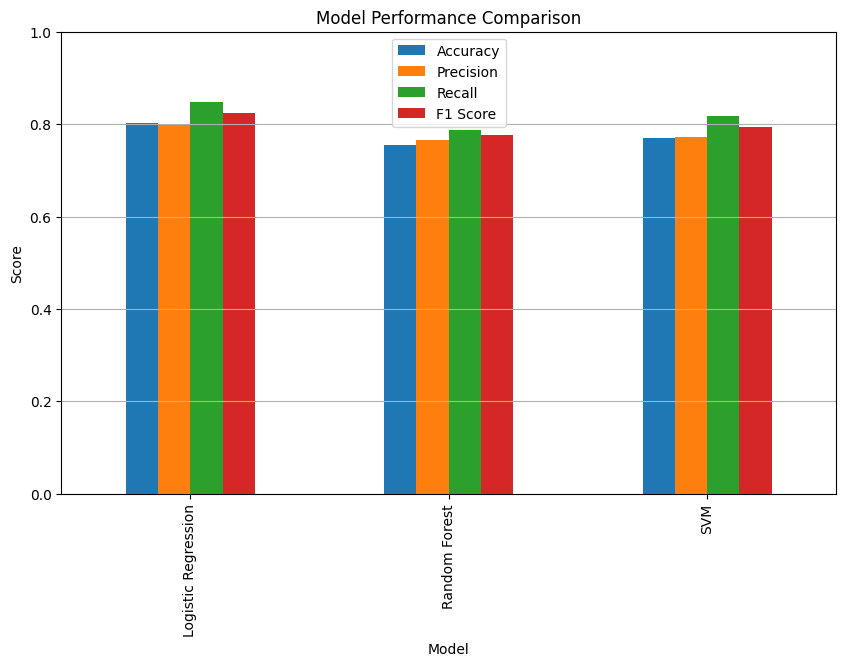

In [14]:
metrics = result_df.set_index("Model")

metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis='y')

plt.show()

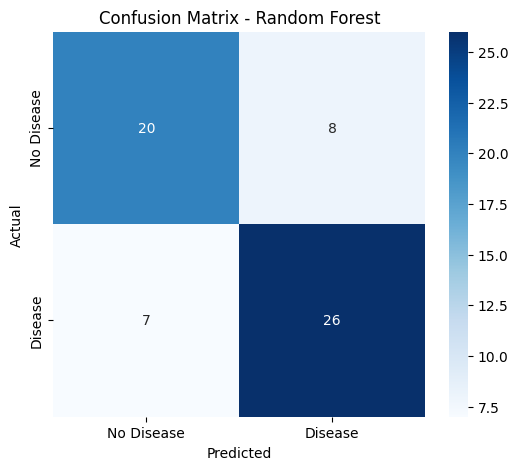

In [15]:
best_model = trained_models["Random Forest"]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

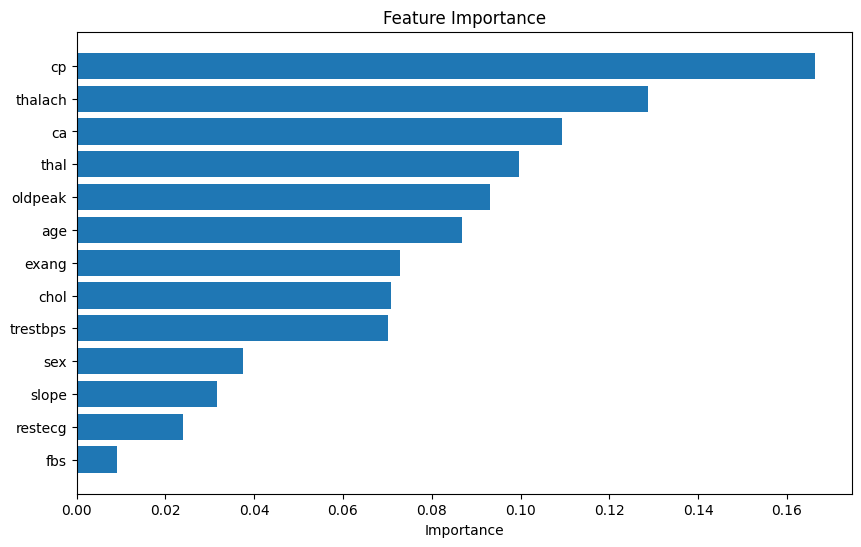

,Feature,Importance
2,cp,0.166320
7,thalach,0.128711
11,ca,0.109447
12,thal,0.099737
9,oldpeak,0.093087
0,age,0.086755
8,exang,0.072760
4,chol,0.070916
3,trestbps,0.070149
1,sex,0.037530


In [16]:
rf = trained_models["Random Forest"]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

importance.sort_values(
    by="Importance",
    ascending=False
)

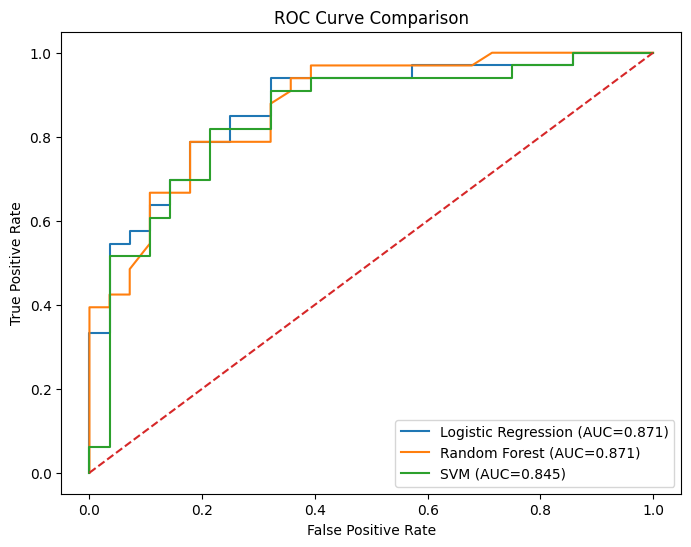

In [17]:
plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=10,
    scoring="accuracy"
)

print("Cross Validation Accuracy:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Accuracy:
[0.83870968 0.87096774 0.76666667 0.83333333 0.86666667 0.93333333
 0.8        0.83333333 0.8        0.8       ]

Average Accuracy:
0.8343010752688172
